/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device cpu
Predictions shape: (899, 32)
Truth shape: (899, 32)


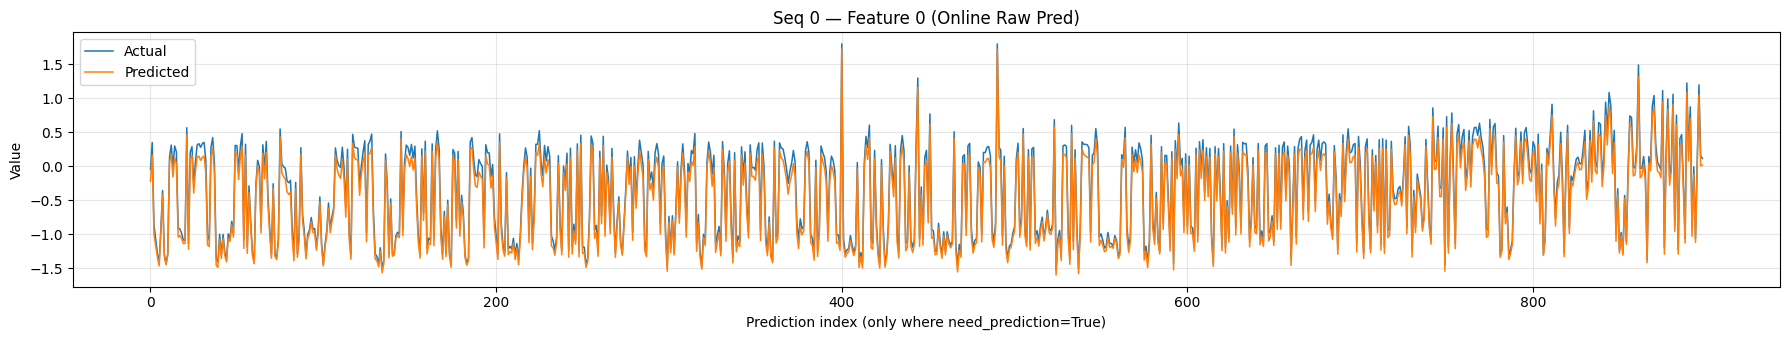

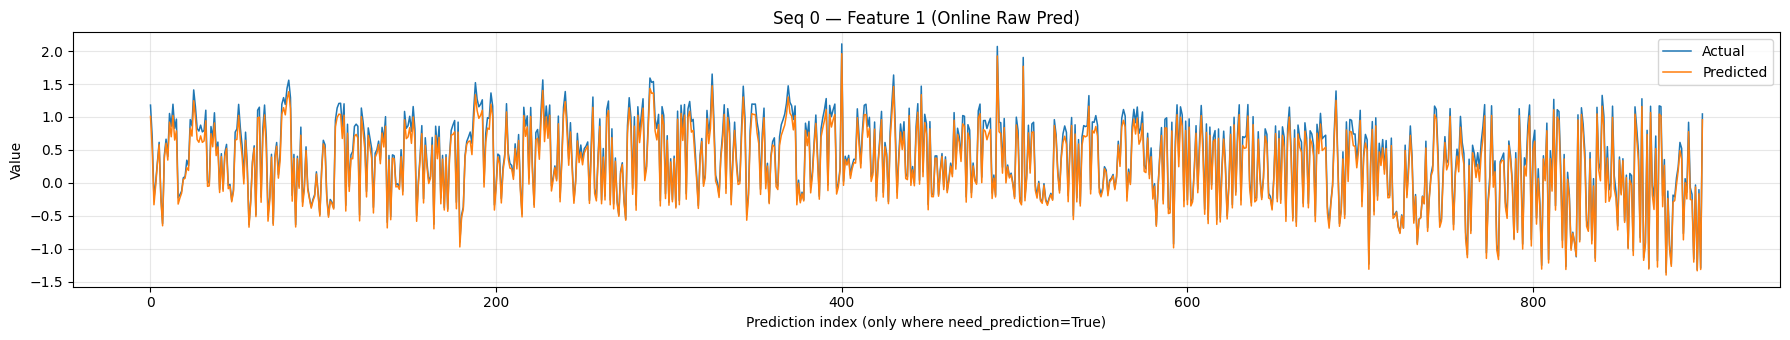

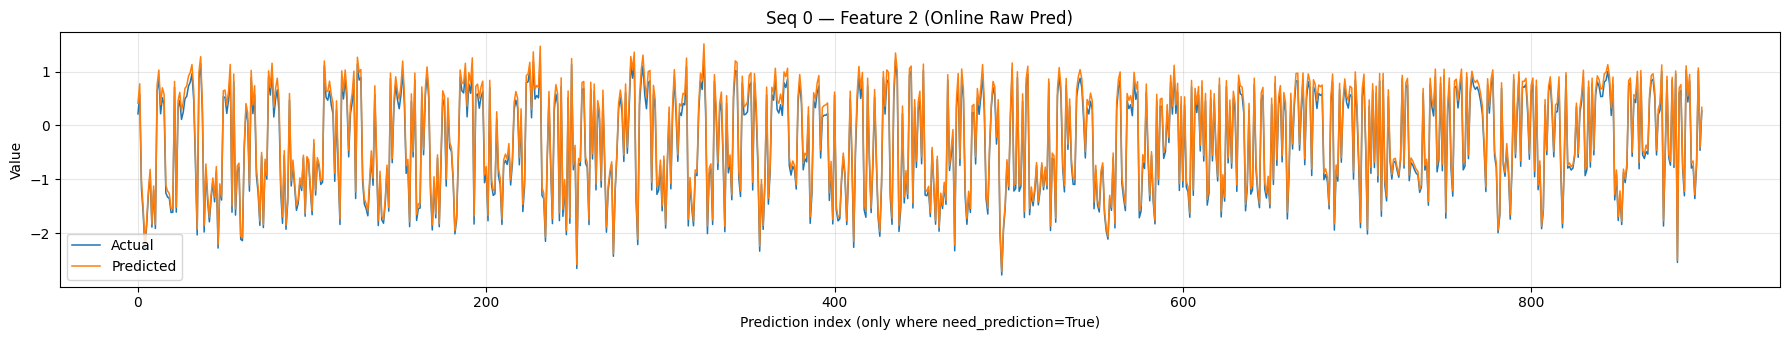

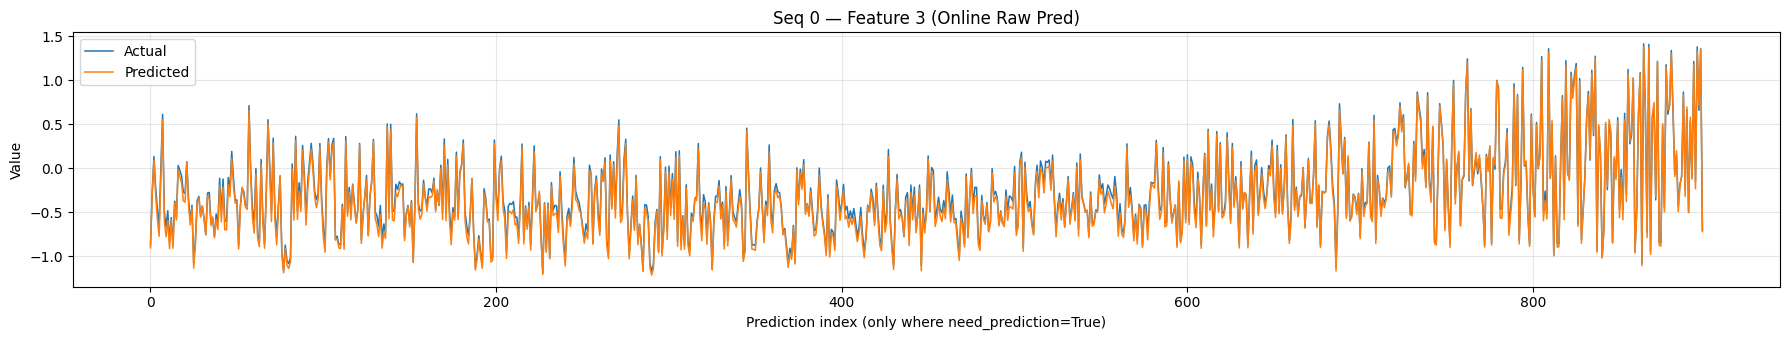

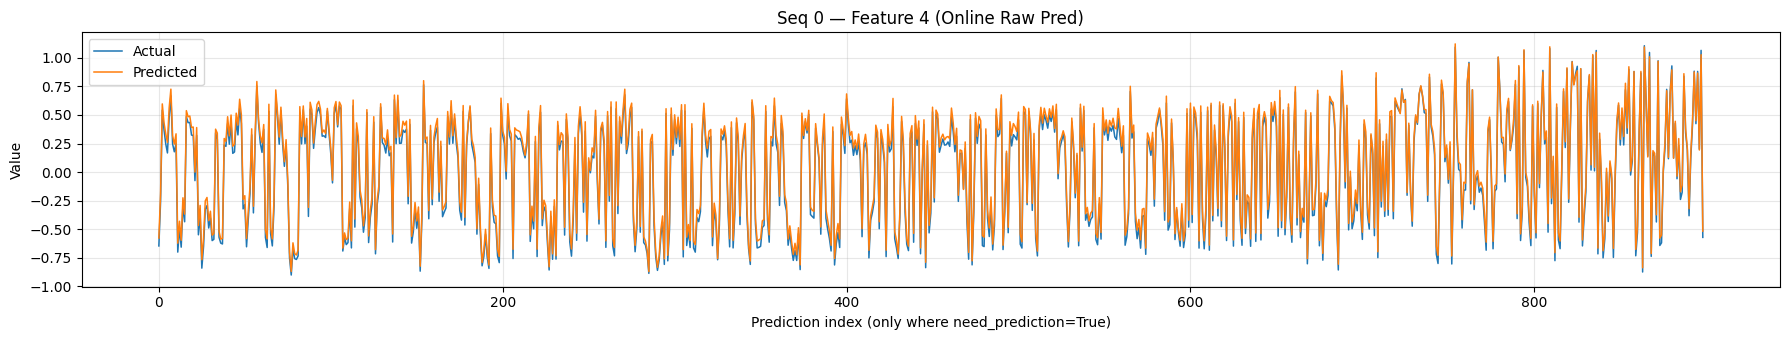

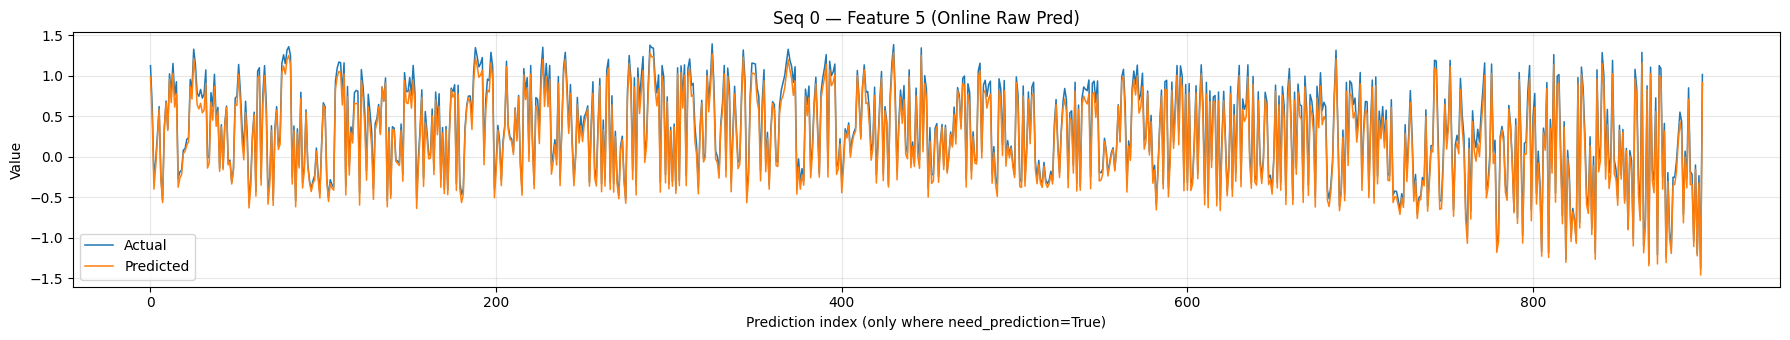

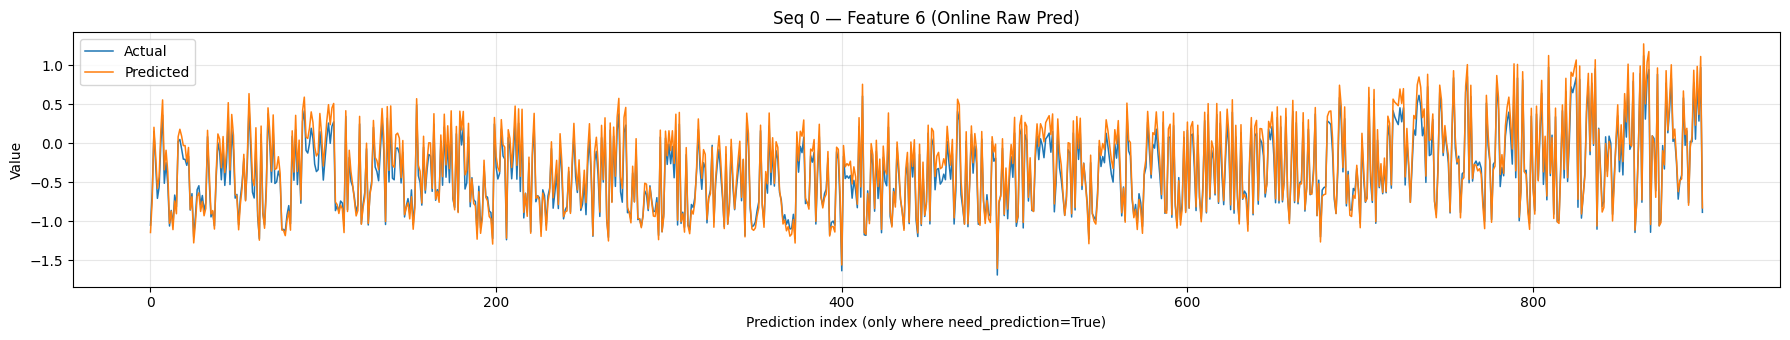

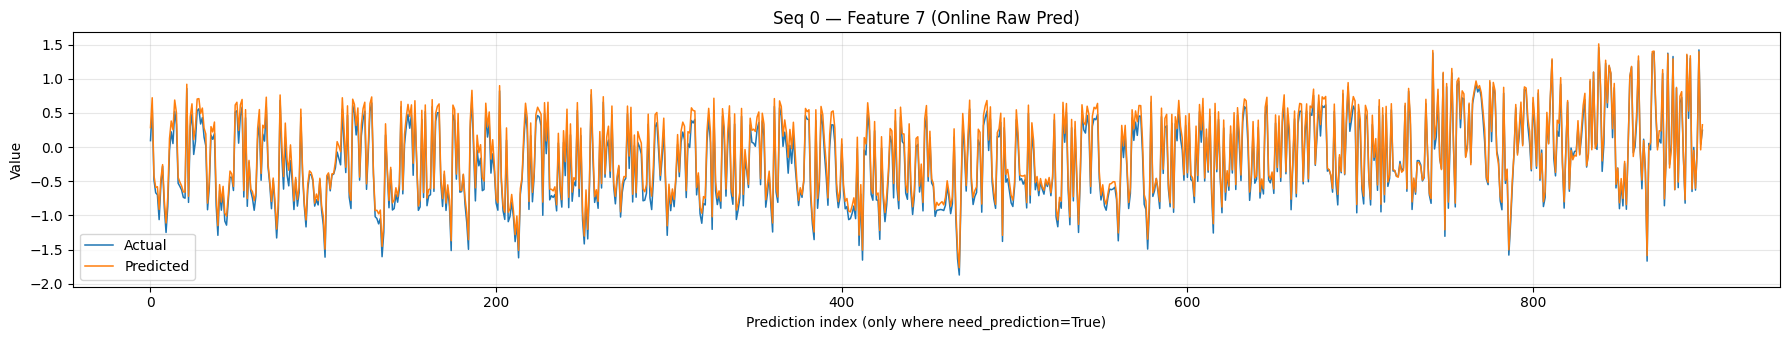

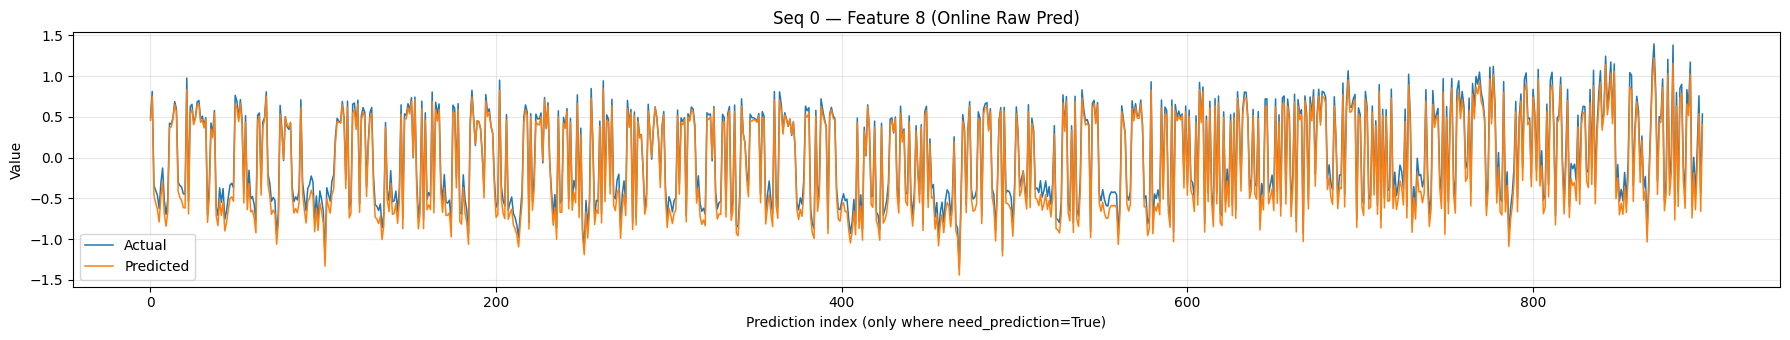

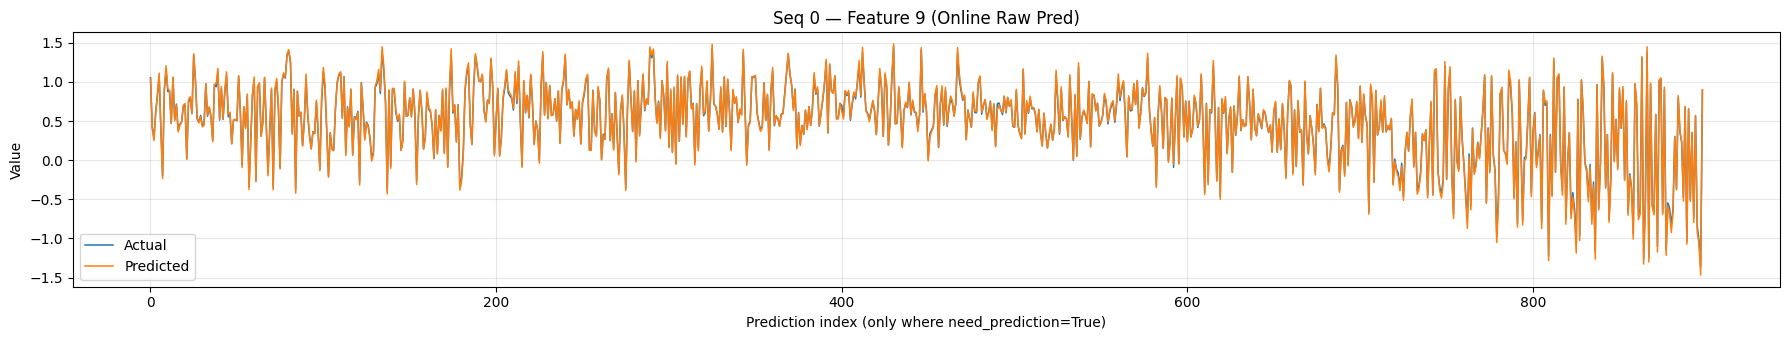

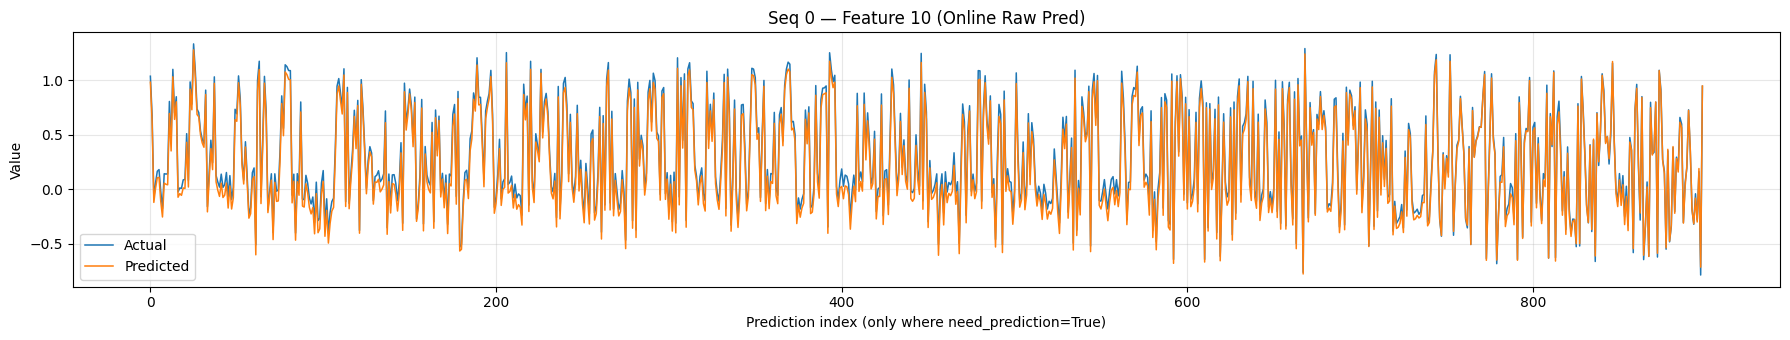

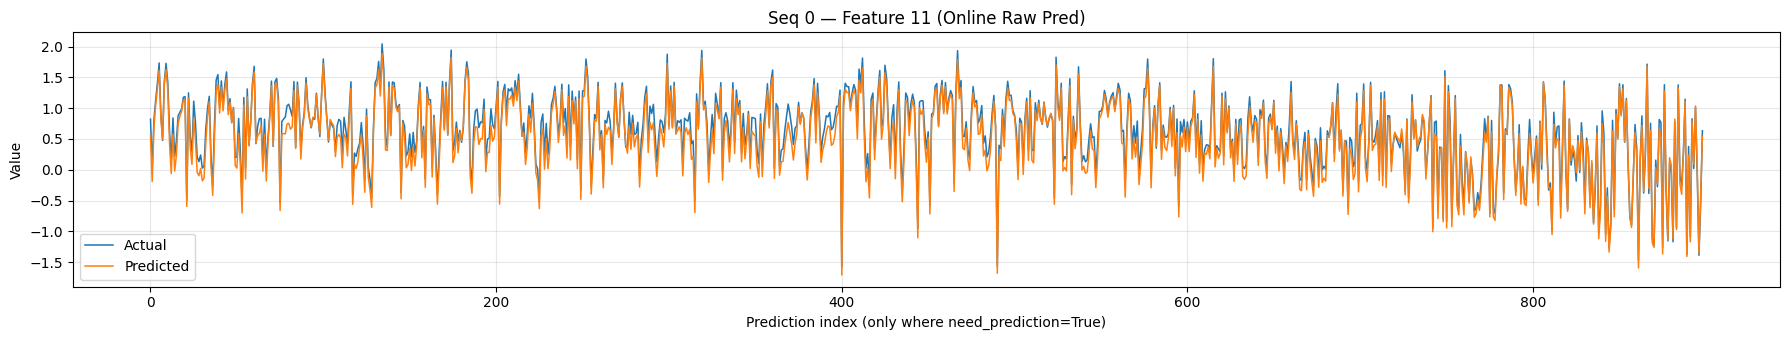

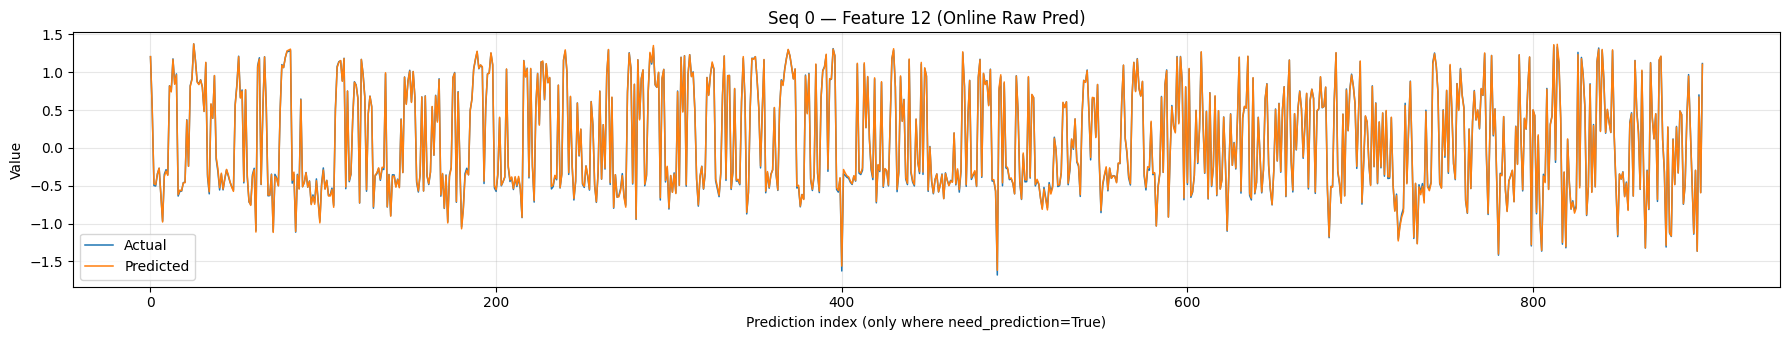

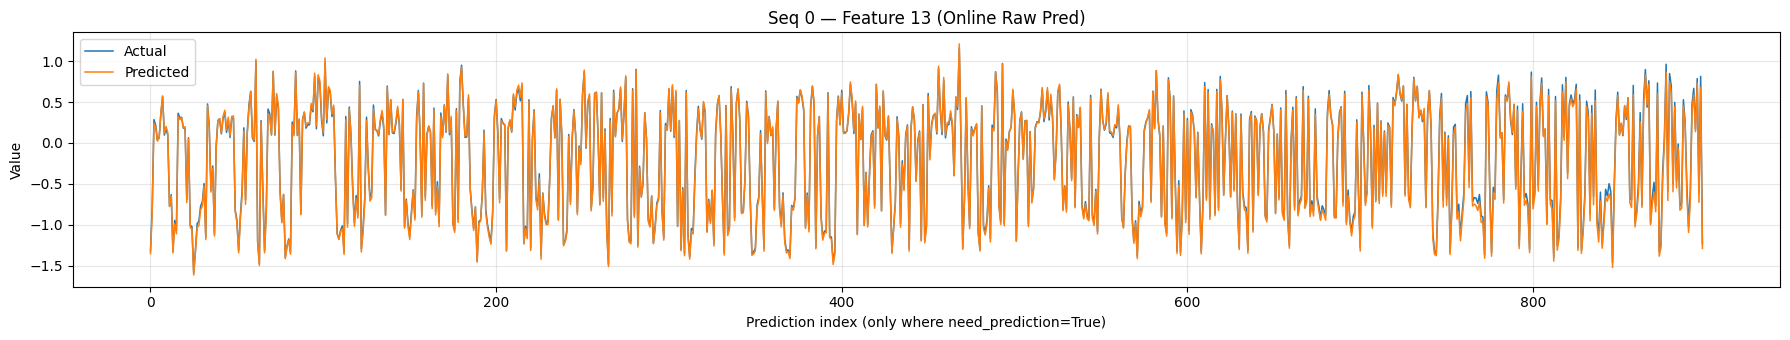

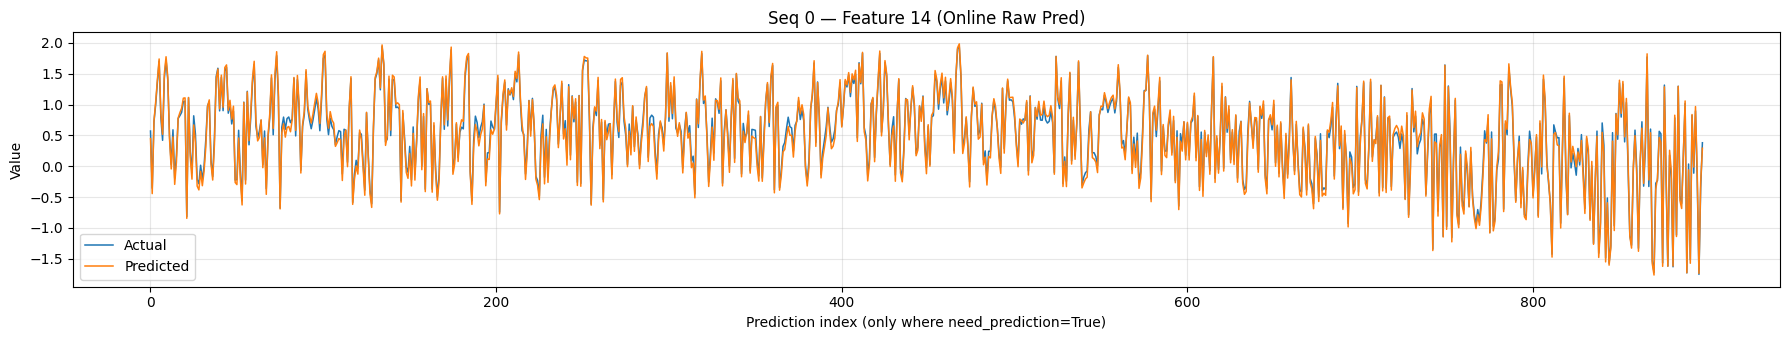

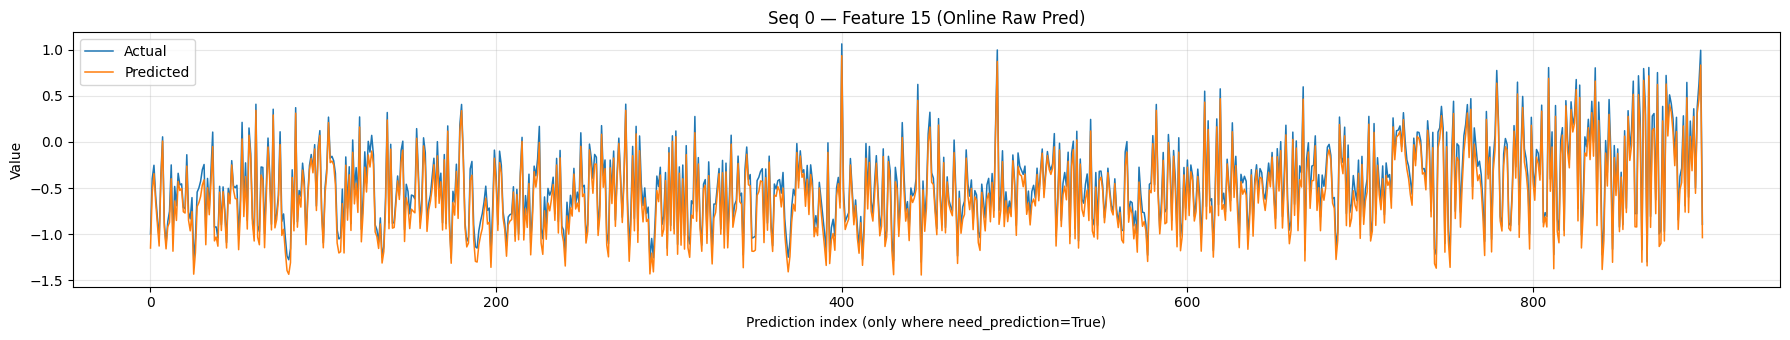

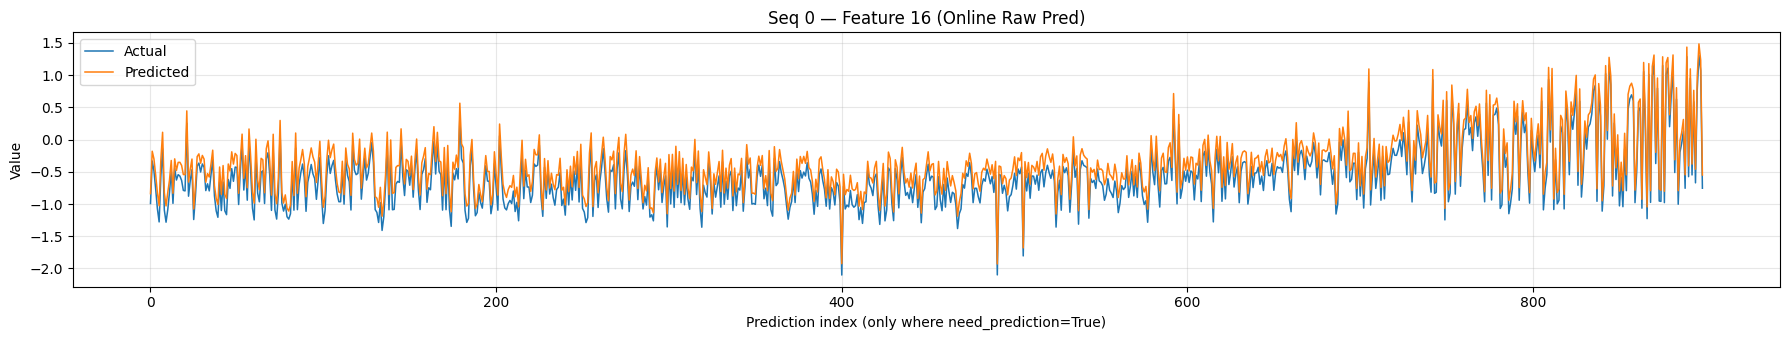

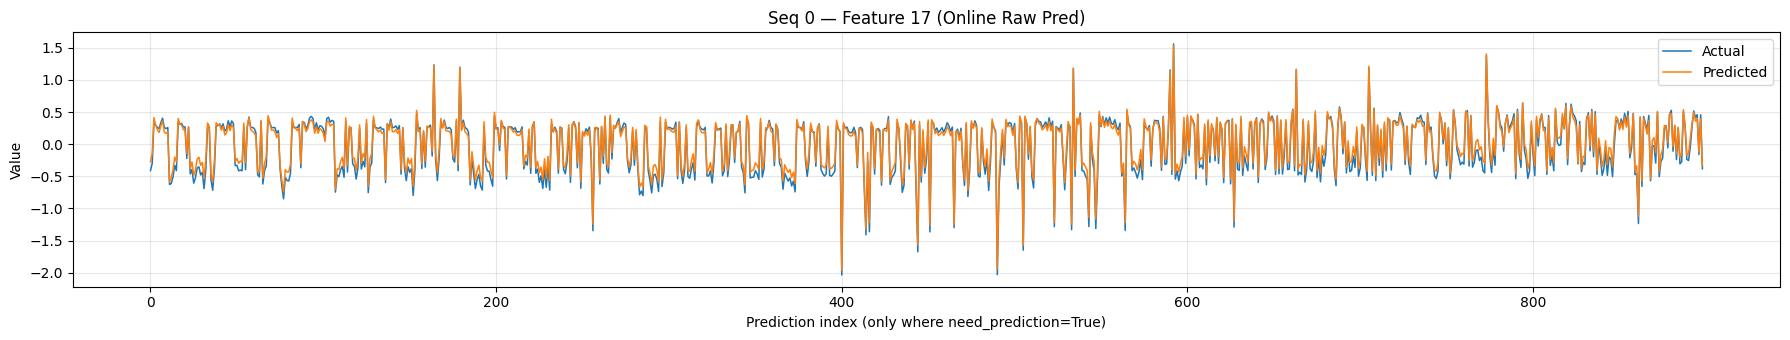

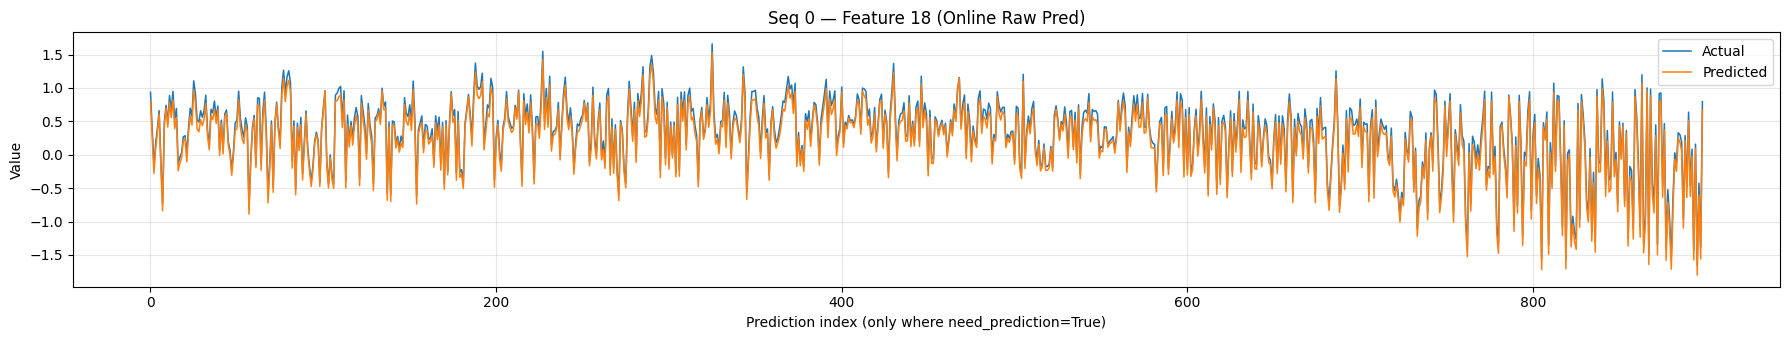

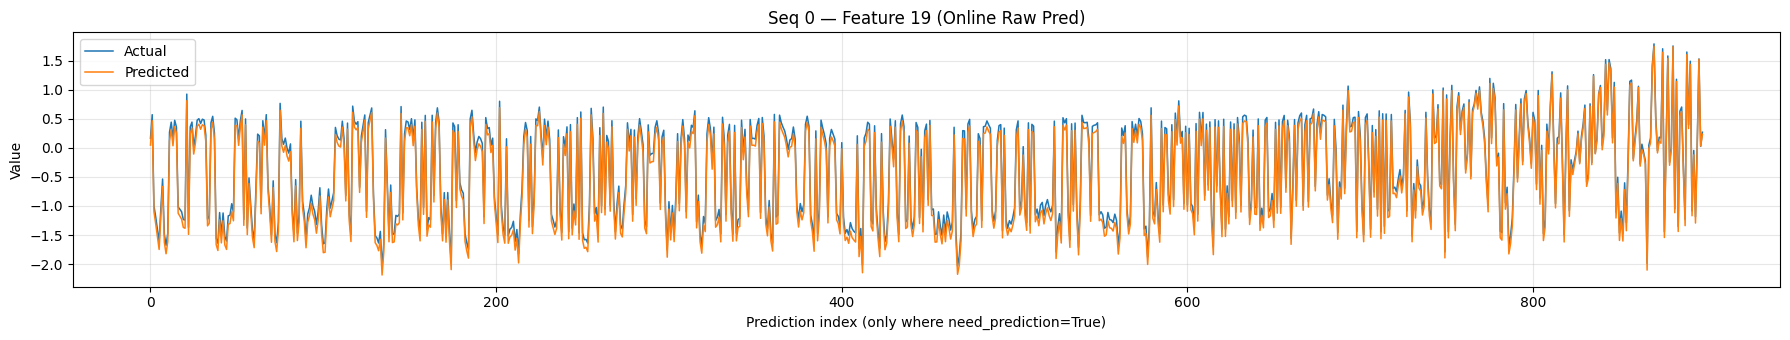

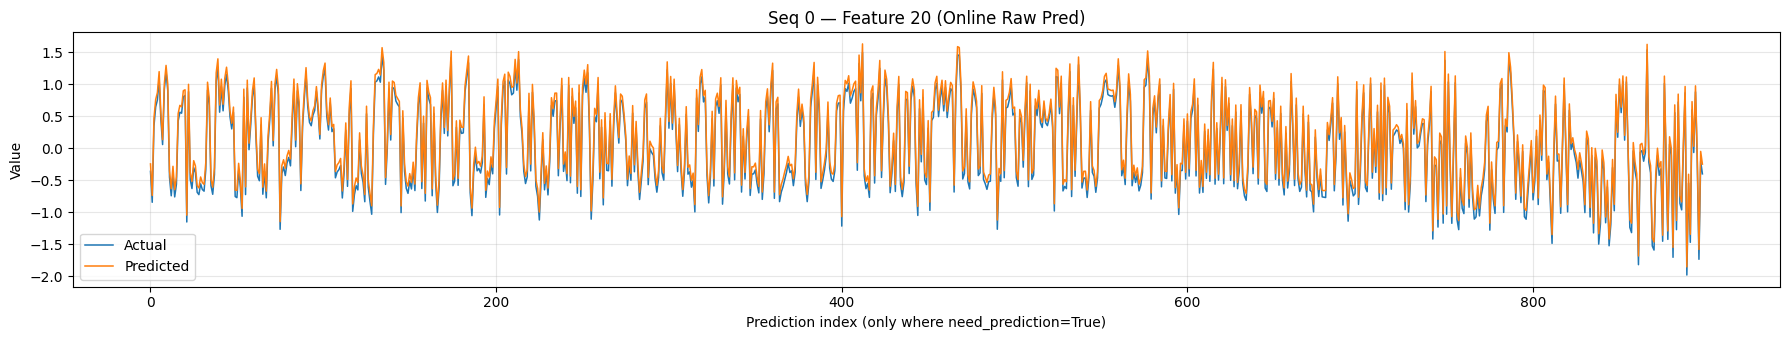

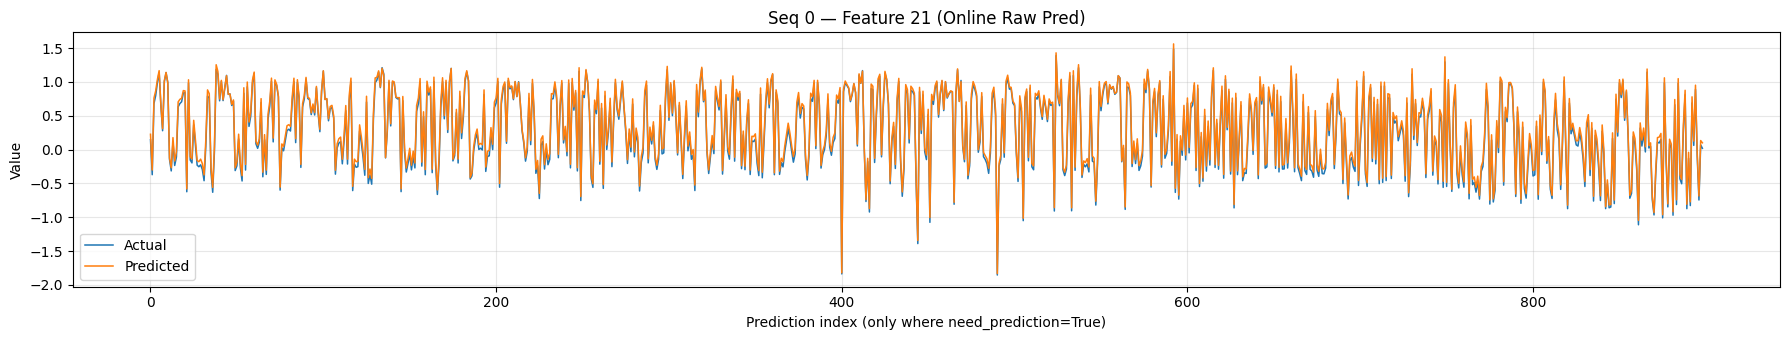

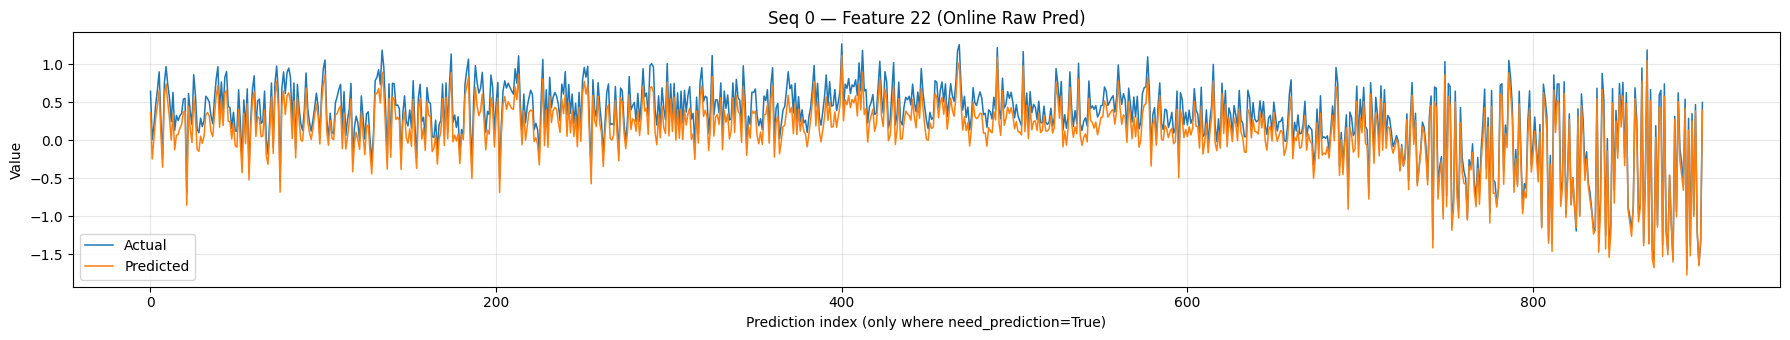

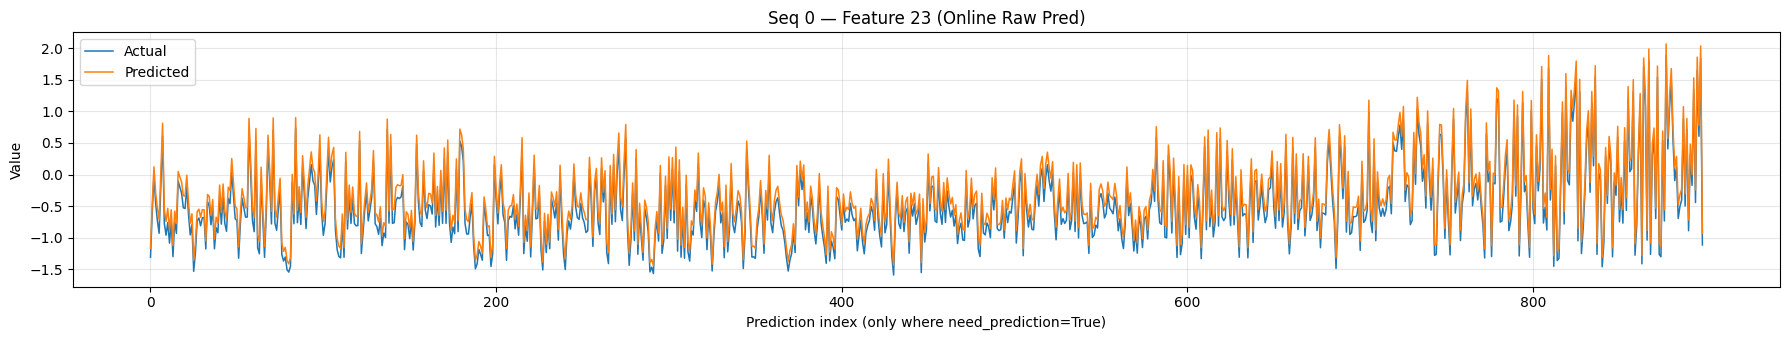

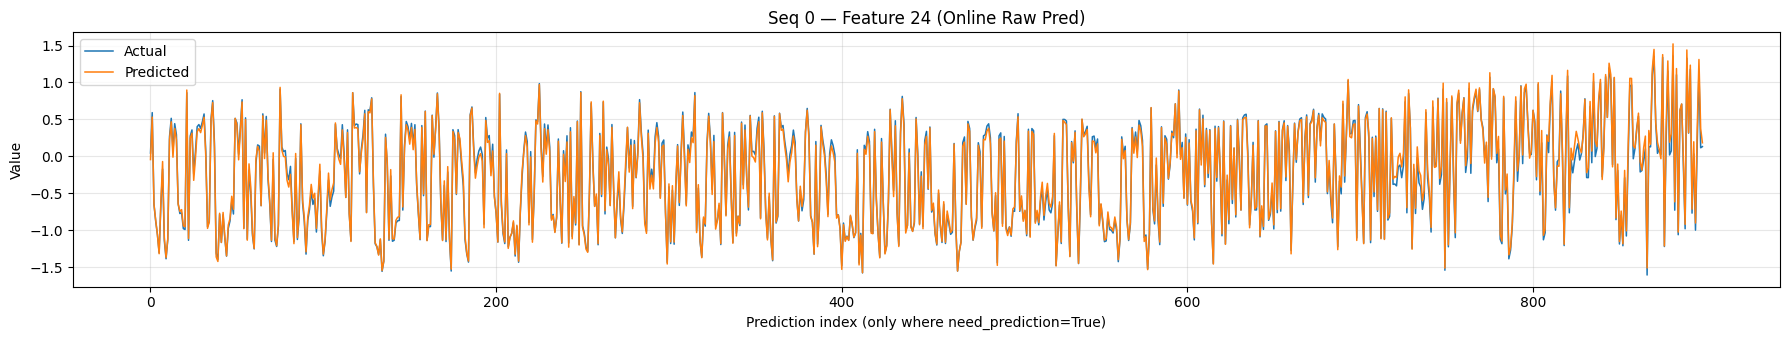

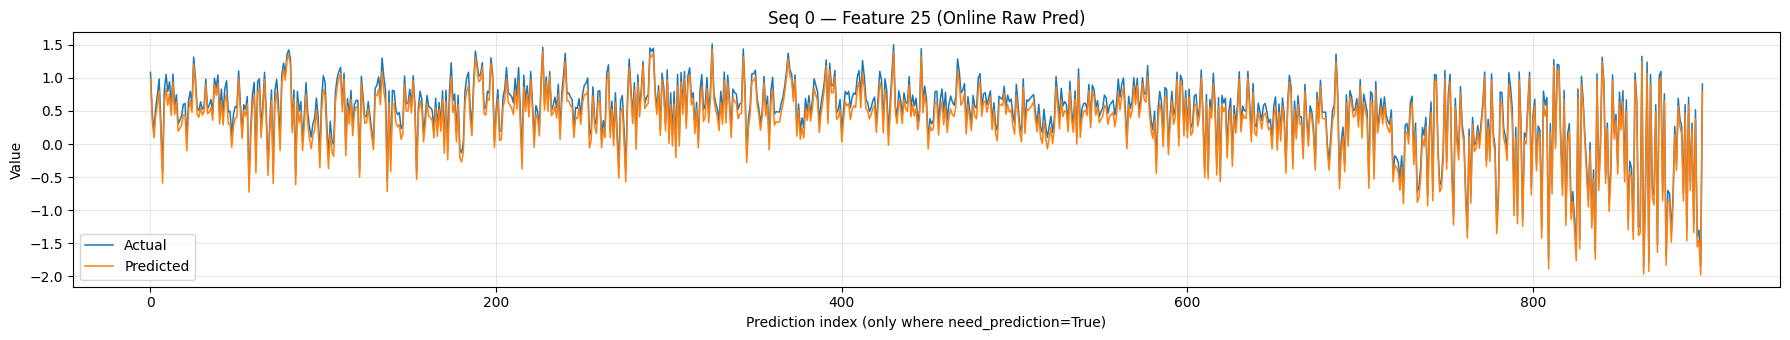

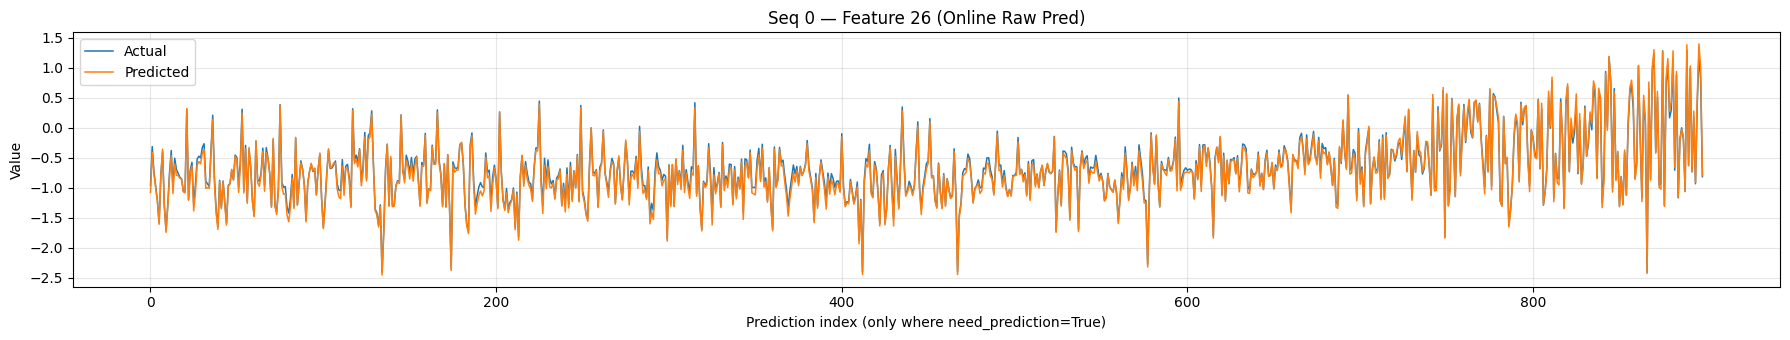

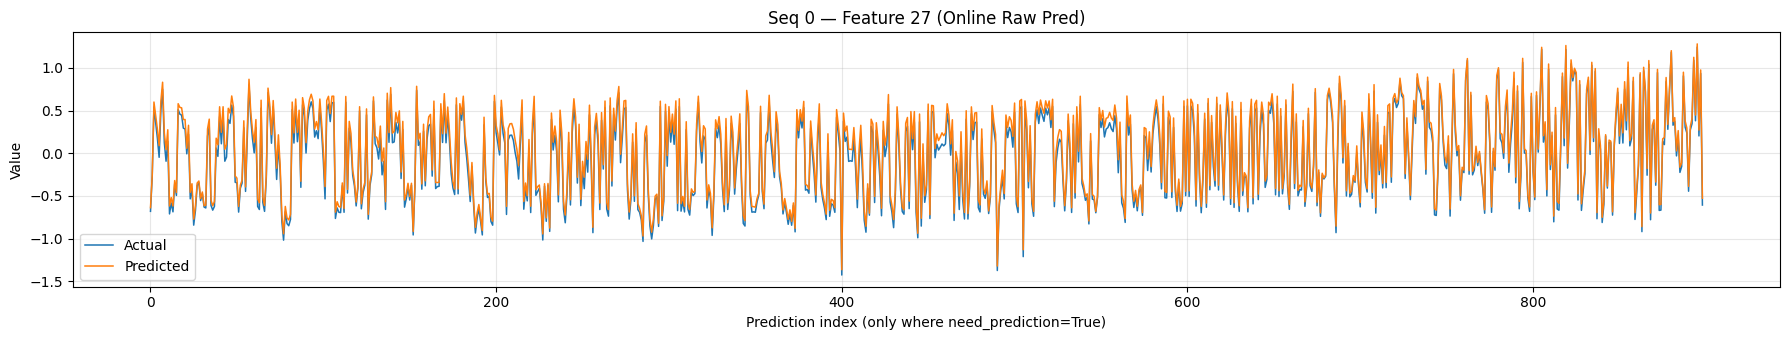

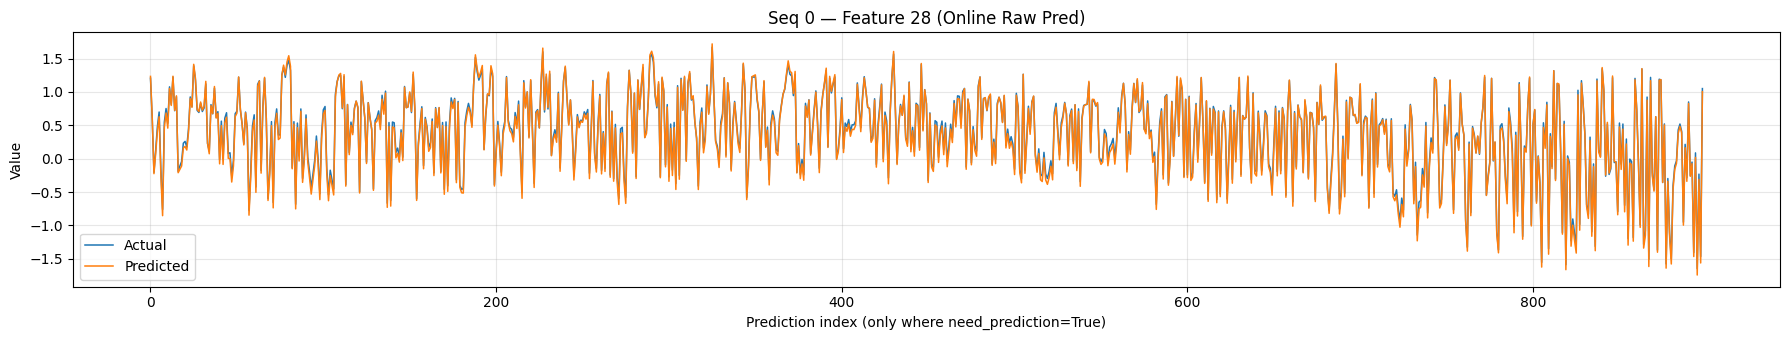

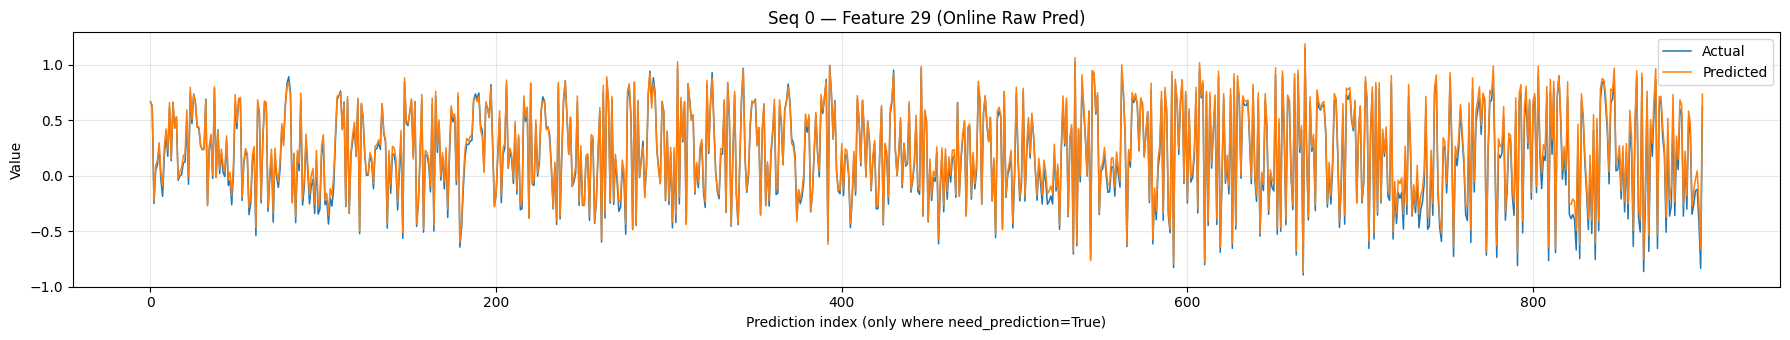

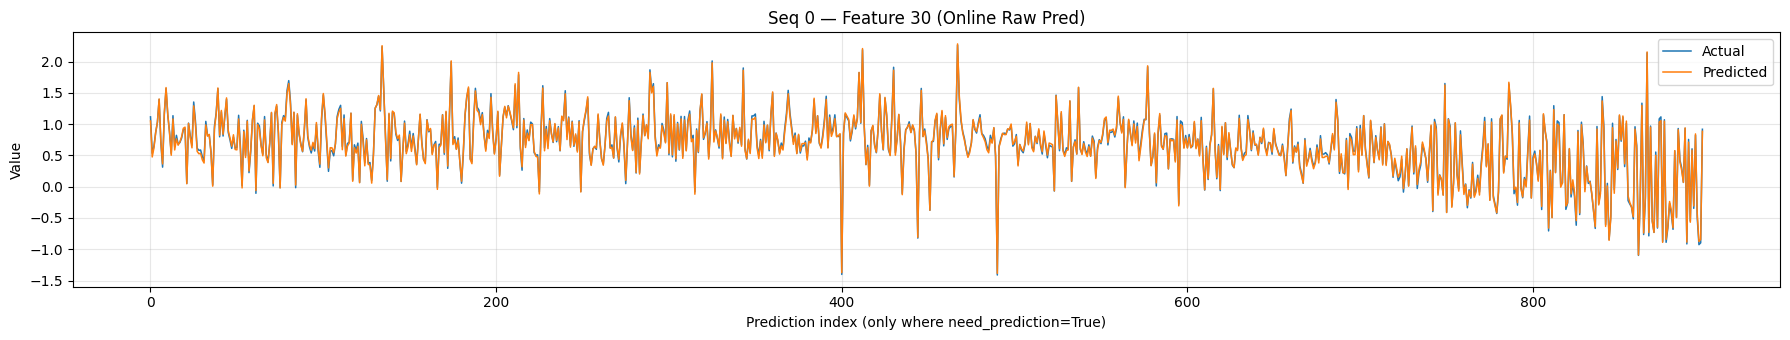

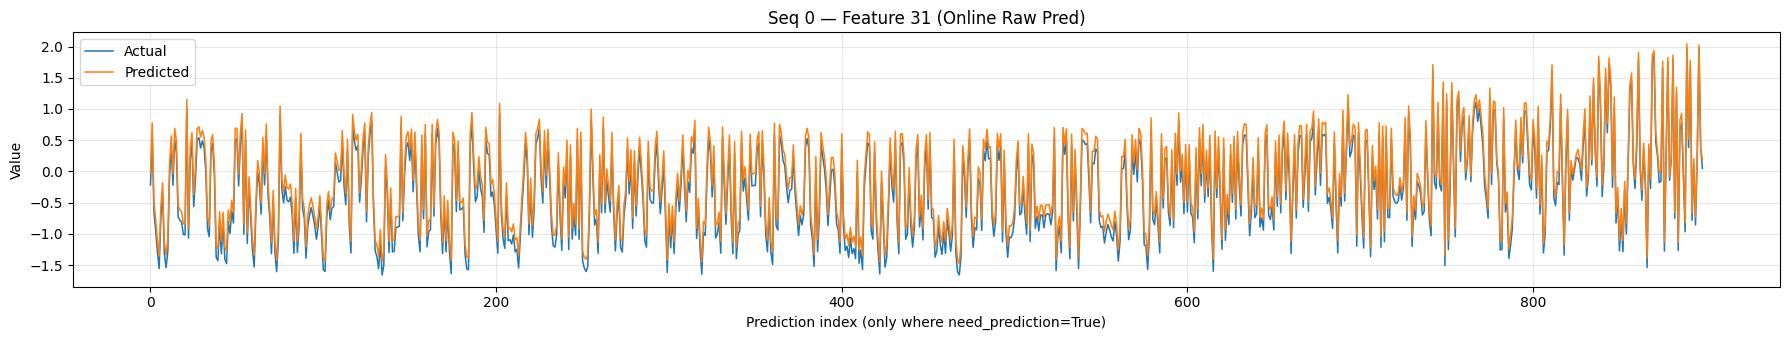


✓ Done plotting.


In [2]:
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ---------------- PATHS + IMPORTS ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CURRENT_DIR = os.getcwd()

# Add utils path (this is correct for competition structure)
sys.path.append(f"{CURRENT_DIR}/../..")
from utils import ScorerStepByStep, DataPoint

# Import model defined inside solution.py
from solution import PredictionModel


# ---------------- USER SETTINGS ----------------
seq_to_plot = 0        # <-- change this to show another sequence
max_points = None      # <-- set e.g. 300 to zoom, or None for full
# ------------------------------------------------


# Load dataset via scorer (ensures identical evaluation order)
train_file = f"{CURRENT_DIR}/../../datasets/train.parquet"
scorer = ScorerStepByStep(train_file)
df = scorer.dataset

# Filter for selected sequence
df_seq = df[df["seq_ix"] == seq_to_plot].sort_values("step_in_seq").reset_index(drop=True)

# Load model (weights + bias handled inside __init__)
model = PredictionModel()
model.eval()

pred_list = []
true_list = []


# ---------- ONLINE PREDICTION LOOP (exact scorer logic) ----------
for _, row in df_seq.iterrows():
    dp = DataPoint(
        int(row["seq_ix"]),
        int(row["step_in_seq"]),
        bool(row["need_prediction"]),
        row[scorer.features].to_numpy(dtype=np.float32)
    )
    pred = model.predict(dp)

    if pred is not None:      # scorer only evaluates on required timesteps
        pred_list.append(pred)
        true_list.append(dp.state)

pred_arr = np.stack(pred_list)
true_arr = np.stack(true_list)

print("Predictions shape:", pred_arr.shape)
print("Truth shape:", true_arr.shape)


# --------- OPTIONAL ZOOM ---------
if max_points is not None:
    pred_arr = pred_arr[:max_points]
    true_arr = true_arr[:max_points]


# ---------------- PLOTTING ----------------
for k in range(32):
    plt.figure(figsize=(18, 3.5))
    plt.plot(true_arr[:, k], label="Actual", linewidth=1.1)
    plt.plot(pred_arr[:, k], label="Predicted", linewidth=1.1)
    plt.title(f"Seq {seq_to_plot} — Feature {k} (Online Raw Pred)")
    plt.xlabel("Prediction index (only where need_prediction=True)")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n✓ Done plotting.")
